# Сглаживание

 

## Упражнения

Загрузите следующие два временных ряда.

In [3]:
# Load the first time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
response.raise_for_status()
smoothing_ts1 = np.load(BytesIO(response.content))
print(len(smoothing_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
response.raise_for_status()
smoothing_ts2 = np.load(BytesIO(response.content))
print(len(smoothing_ts2))

144
1000


Используя то, что вы узнали в этой и предыдущих лекциях, выполните следующие действия.

1. Создайте две временные переменные с именами `mytime1` и `mytime2`, которые начинаются с 0 и имеют такую ​​же длину, как и каждый набор данных.
2. Разделите каждый набор данных на обучающий и тестовый наборы (в качестве теста используйте последние 5 наблюдений).
3. Определите тренд и сезонность, если они присутствуют.
4. Определите, являются ли тренд и/или сезонность аддитивными или мультипликативными, если они присутствуют.
5. Создайте сглаженную модель на обучающем наборе и используйте ее для прогнозирования на тестовом наборе.
6. Рассчитайте MSE на тестовых данных.
7. Нанесите на график обучающие данные, тестовые данные и прогноз вашей модели для каждого набора данных.

# _______________________________________________________________________________________________________

In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

# Загрузка данных
response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
smoothing_ts1 = np.load(BytesIO(response.content))

response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
smoothing_ts2 = np.load(BytesIO(response.content))

print(len(smoothing_ts1), len(smoothing_ts2))


144 1000


Создаём переменные времени, начинающиеся с 0

In [5]:
mytime1 = np.arange(len(smoothing_ts1))
mytime2 = np.arange(len(smoothing_ts2))

разделяем train/test, Последние 5 наблюдений в тестовый набор

In [6]:
train1, test1 = smoothing_ts1[:-5], smoothing_ts1[-5:]
train2, test2 = smoothing_ts2[:-5], smoothing_ts2[-5:]

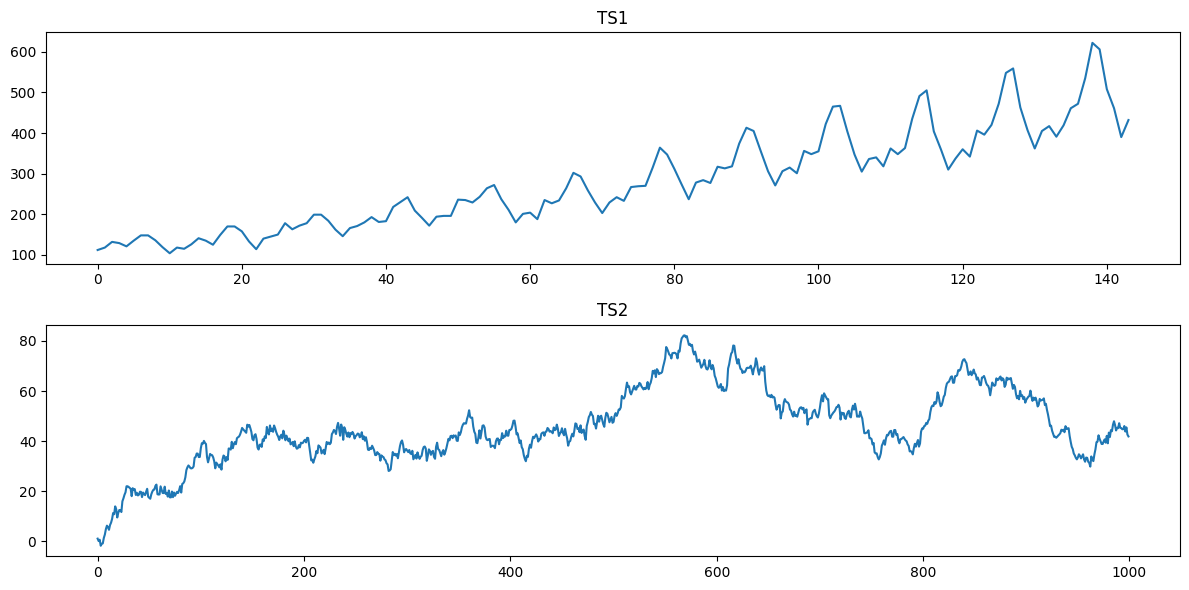

In [7]:
def mse(observations, estimates):
    assert len(observations) == len(estimates)
    return np.mean((np.array(observations) - np.array(estimates)) ** 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(mytime1, smoothing_ts1); axes[0].set_title("TS1")
axes[1].plot(mytime2, smoothing_ts2); axes[1].set_title("TS2")
plt.tight_layout()
plt.show()

TS1 наблюдается линейный тренд (рост) без заметной сезонности. Колебания вокруг тренда носят случайный характер (шум). 
TS2 есть тренд, ьакже присутствует периодическая сезонная составляющая (регулярные колебания). Необходимо определить тип сезонности (аддитивная или мультипликативная).

 если амплитуда колебаний остаётся постоянной - аддитивная; если она пропорционально увеличивается вместе с уровнем ряда - мультипликативная

#### Декомпозиция

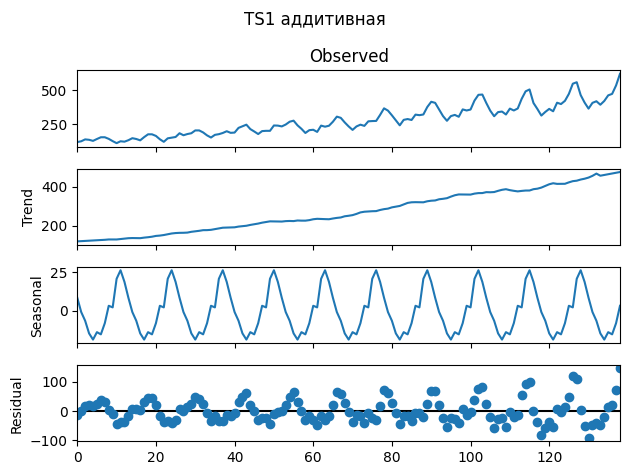

In [8]:
# TS1 (аддитивная)
decomp1 = seasonal_decompose(train1, model='additive', period=13, extrapolate_trend='freq')
decomp1.plot(); plt.suptitle("TS1 аддитивная"); plt.tight_layout(); plt.show()

TS1 аддитивный тренд + аддитивная сезонность + шум

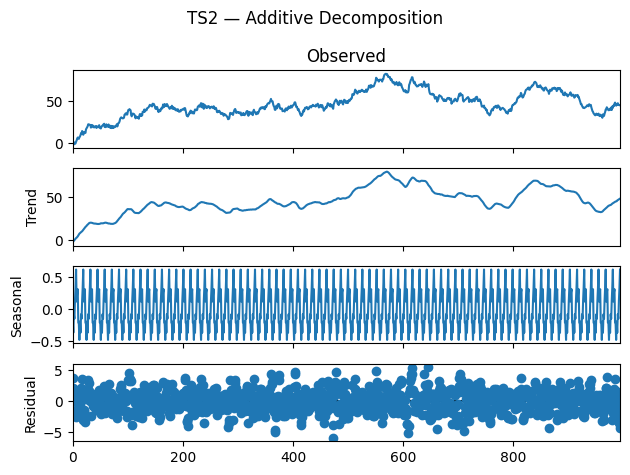

In [9]:
# Декомпозиция TS2 (мультипликативная)
decomp2 = seasonal_decompose(train2, model='additive', period=13, extrapolate_trend='freq')
decomp2.plot(); plt.suptitle("TS2 — Additive Decomposition"); plt.tight_layout(); plt.show()

TS2 содержит нелинейный тренд + аддитивную сезонность. Поскольку ряд включает нулевые значения, мультипликативная модель неприменима, интерпертатор ругался

#### Обучение моделей

In [10]:
# TS1
model1 = Holt(train1).fit(optimized=True)
preds1 = model1.forecast(5)
mse1 = mse(test1, preds1)
print(f"TS1 — Holt (Double ES) MSE: {mse1:.4f}")
print(f"  alpha={model1.params['smoothing_level']:.4f}, "
      f"beta={model1.params['smoothing_trend']:.4f}")

TS1 — Holt (Double ES) MSE: 32467.3996
  alpha=1.0000, beta=0.0000


In [12]:
# TS2
model2 = ExponentialSmoothing(
    train2,
    trend='additive',
    seasonal='additive', # тк в нашем ряде есть 0 значение, то только аддитивная...
    seasonal_periods=13          
).fit(optimized=True)
preds2 = model2.forecast(5)
mse2 = mse(test2, preds2)
print(f"TS2 — Holt-Winters (Triple ES, mult.) MSE: {mse2:.4f}")
print(f"  alpha={model2.params['smoothing_level']:.4f}, "
      f"beta={model2.params['smoothing_trend']:.4f}, "
      f"gamma={model2.params['smoothing_seasonal']:.4f}")

TS2 — Holt-Winters (Triple ES, mult.) MSE: 2.2793
  alpha=1.0000, beta=0.0000, gamma=0.0000


TS1 плохо поддаётся модели Holt оптимизатор нашёл вырожденное решение (alpha=1, beta=0), что даёт наивный прогноз и огромную ошибку MSE=32467, поэтому для этого ряда нужно пересмотреть подход. TS2 прогнозируется точно (MSE=2.28) 

График TS1

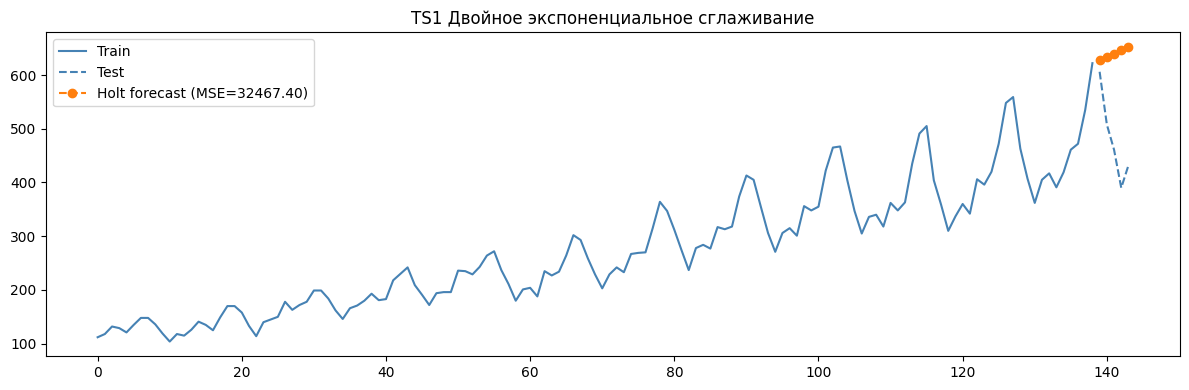

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mytime1[:-5], train1, label="Train", color='steelblue')
ax.plot(mytime1[-5:], test1,  label="Test",  color='steelblue', linestyle='--')
ax.plot(mytime1[-5:], preds1, label=f"Holt forecast (MSE={mse1:.2f})",
        color='tab:orange', linestyle='--', marker='o')
ax.set_title("TS1 Двойное экспоненциальное сглаживание")
ax.legend(); plt.tight_layout(); plt.show()


Holt не смог корректно уловить тренд TS1. Для улучшения стоит попробовать дать явные начальные значения параметров

График TS2

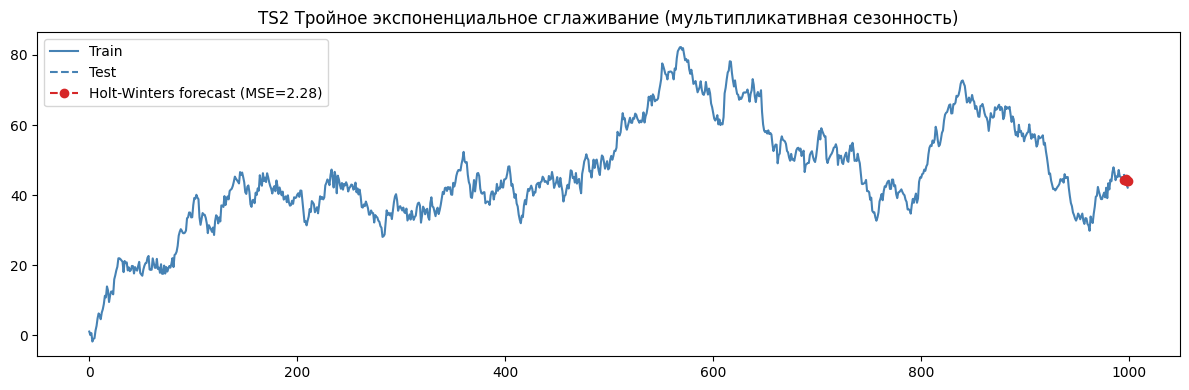

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mytime2[:-5], train2, label="Train", color='steelblue')
ax.plot(mytime2[-5:], test2,  label="Test",  color='steelblue', linestyle='--')
ax.plot(mytime2[-5:], preds2, label=f"Holt-Winters forecast (MSE={mse2:.2f})",
        color='tab:red', linestyle='--', marker='o')
ax.set_title("TS2 Тройное экспоненциальное сглаживание (мультипликативная сезонность)")
ax.legend(); plt.tight_layout(); plt.show()


Тройное экспоненциальное сглаживание отлично подходит для TS2 благодаря явной сезонности и тренду. Аддитивная модель оправдана, амплитуда колебаний не увеличивается пропорционально уровню ряда